In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Network

## Template 03
## FIFA dataset Using PYTORCH


<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [2]:
###-----------------
### Import libraries
###-----------------
import sys
from pathlib import Path

# Add current directory to path for local imports
sys.path.insert(0, str(Path.cwd()))

import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler, LabelEncoder  # Import for standardizing features (zero mean, unit variance)

from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix # Custom utility 

import pydot

import torch
import torch.nn as nn  # Import PyTorch's neural network module for building and training neural networks
from torchsummary import summary  # Import function to summarize the model architecture and parameters
from torch.utils.data import Dataset, DataLoader


In [3]:
import pydot
print(pydot.__version__)  # check what version you have

# Correct verification for pydot v2.x
graphs = pydot.graph_from_dot_data('digraph { a -> b }')
print(graphs)  # if this returns a list (not None/error), graphviz is found

4.0.1


In [4]:
# print (fn_plot_confusion_matrix.__doc__)

In [5]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'
subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 101 # number of epochs
BATCH_SIZE = 32     # Look at train size too!!!
ALPHA = 0.001 # learning rate
#TEST_SIZE = 0.2
TRAIN_SIZE = 453*BATCH_SIZE    # Good for 32 Batch_size

# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## Basic Hygiene

In [6]:
# Check if all directories are present
outDir.mkdir(parents=True, exist_ok=True)

modelSubDir = modelDir/ subDir
modelSubDir.mkdir(parents=True, exist_ok=True)

## Read FIFA 2019 data set

In [7]:
data_df = pd.read_csv('D:/Deep_Learning/SharedData/fifa_2019.csv')
data_df.shape

(18207, 89)

In [8]:
# removing rows with position = null
data_df = data_df[data_df["Position"].notnull()]
data_df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [9]:
# Following columns appear to be relevant for our analysis
rel_cols = ["Position", 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
            'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
            'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
            'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
            'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
            'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
            'GKKicking', 'GKPositioning', 'GKReflexes']

In [10]:
goalkeeper = 'GK'
forward = ['ST', 'LW', 'RW', 'LF', 'RF', 'RS','LS', 'CF']
midfielder = ['CM','RCM','LCM', 'CDM','RDM','LDM', 'CAM', 'LAM', 'RAM', 'RM', 'LM']
defender = ['CB', 'RCB', 'LCB', 'LWB', 'RWB', 'LB', 'RB']

In [11]:
data_df = data_df[rel_cols]
data_df.head()

,Position,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,RF,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0
1,ST,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0
2,LW,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0
3,GK,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0
4,RCM,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0


In [12]:
#Assign labels to goalkeepers

data_df['Position_encoded'] = 0

data_df.loc[data_df["Position"] == "GK", "Position"] = 0

#Defenders
data_df.loc[data_df["Position"].isin(defender), "Position"] = 1

#Midfielders
data_df.loc[data_df["Position"].isin(midfielder), "Position"] = 2

#Forward
data_df.loc[data_df["Position"].isin(forward), "Position"] = 3

# Convert Column "Position" to numeric so that Pandas does not complain
data_df['Position_encoded'] = pd.to_numeric(data_df['Position'], downcast="integer")

In [13]:
data_df['Position_encoded']

0        3
1        3
2        3
3        0
4        2
        ..
18202    2
18203    3
18204    3
18205    3
18206    2
Name: Position_encoded, Length: 18147, dtype: int8

In [14]:
labels = data_df['Position_encoded']
features = data_df.drop(['Position', 'Position_encoded'], axis = 1)

In [15]:
class_names = {0: 'Goal Keeper', 1: 'Defender', 2: 'Mid-Fielder', 3: 'Forward'}

In [16]:
# splitting in train ans test datasets
X_train,X_test,y_train,y_test = train_test_split(features,labels,
                                     stratify=labels,
                                     test_size=TRAIN_SIZE, 
                                     random_state=RANDOM_STATE )

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3651, 33), (3651,), (14496, 33), (14496,))

In [17]:
list(class_names.keys())

[0, 1, 2, 3]

In [18]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## DATASETS

In [20]:
class FifaDataset(Dataset):
    
    def __init__(self, X, y):
        super().__init__()
        self.X = torch.tensor (X, dtype=torch.float32)
        self.y = torch.tensor (y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
    

In [21]:
train_dataset = FifaDataset(X_train, y_train.to_numpy())
train_loader = DataLoader(dataset = train_dataset, batch_size=BATCH_SIZE, shuffle=True)

for batch_idx, (data, target) in enumerate(train_loader):
    print (f'Batch: {batch_idx + 1}: ', end='')
    print (f'Data: {data.shape}: ', end='')
    print (f'Target: {target.shape}: ')

Batch: 1: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 2: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 3: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 4: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 5: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 6: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 7: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 8: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 9: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 10: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 11: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 12: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 13: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 14: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 15: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 16: Data: to

In [22]:
# X_train.shape, X_test.shape, 453*32 + 21

In [23]:
test_dataset = FifaDataset(X_test, y_test.to_numpy())
test_loader = DataLoader(dataset = test_dataset, batch_size=BATCH_SIZE, shuffle=True)

for batch_idx, (data, target) in enumerate(test_loader):
    print (f'Batch: {batch_idx + 1}: ', end='')
    print (f'Data: {data.shape}: ', end='')
    print (f'Target: {target.shape}: ')

Batch: 1: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 2: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 3: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 4: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 5: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 6: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 7: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 8: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 9: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 10: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 11: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 12: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 13: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 14: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 15: Data: torch.Size([32, 33]): Target: torch.Size([32]): 
Batch: 16: Data: to

## Define Model

In [24]:
class FifaModel(nn.Module):
    '''Layers
        33 -> 16 -> 8 -> 4'''
    
    def __init__(self, input_dim):
        super(FifaModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.active1 = nn.ReLU()
        self.layer2 = nn.Linear(16, 8)
        self.active2 = nn.ReLU()
        self.layer3 = nn.Linear(8, 4)
        
    def forward(self, X):
        X = self.layer1(X)
        X = self.active1(X)
        X = self.layer2(X)
        X = self.active2(X)
        X = self.layer3(X)
        return X
    
model = FifaModel(input_dim=X_train.shape[1]).to(device=device)

In [28]:

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = ALPHA)

loss, tloss, n_epoch, acc, tacc = [],[],[],[],[]


for epoch in range(EPOCHS):
    model.train()
    
    epoch_loss = 0
    epoch_acc = 0
    tepoch_loss = 0
    tepoch_acc = 0
    
    for batch_idx, (train_X, train_y) in enumerate(train_loader):
        train_X, train_y, = train_X.to(device), train_y.to(device)
        
        predict_prob = model(train_X)
        batch_loss = loss_fn(predict_prob, train_y)
        epoch_loss += (batch_loss - epoch_loss) / (batch_idx + 1) 
        
    
        optimizer.zero_grad()       # reset gradients to zero
        batch_loss.backward()             # backpropogation to compute gradients
        optimizer.step()            # update model parameters using optimizer
        

        _, y_pred = torch.max(predict_prob , 1)      # predict class
        
        batch_acc = accuracy_score(train_y.cpu().numpy(),
                                   y_pred.data.cpu())
        
        epoch_acc += (batch_acc - epoch_acc) / (batch_idx + 1)
        
    loss.append(epoch_loss.data.item())
    acc.append(epoch_acc)
    
    model.eval()  ## stop leearning
    
    
    
    
    with torch.inference_mode():
        for batch_idx, (test_X, test_y) in enumerate(test_loader):
            test_X, test_y, = test_X.to(device), test_y.to(device)
        
            predict_prob_tst = model(test_X)
            tbatch_loss = loss_fn(predict_prob_tst, test_y)
            tepoch_loss += (tbatch_loss - tepoch_loss) / (batch_idx + 1) 
            
        
            # optimizer.zero_grad()       # reset gradients to zero
            # batch_loss.backward()             # backpropogation to compute gradients
            # optimizer.step()            # update model parameters using optimizer
            

            _, y_pred = torch.max(predict_prob_tst , 1)      # predict class
            
            tbatch_acc = accuracy_score(test_y.cpu().numpy(),
                                    y_pred.data.cpu())
            
            tepoch_acc += (tbatch_acc - tepoch_acc) / (batch_idx + 1)
            
    tloss.append(tepoch_loss.data.item())
    tacc.append(tepoch_acc)
    
    n_epoch.append(epoch)
        
    
    if epoch % 20 == 0:
        fmtstr = 'Epoch: {:5d} / {:5d} | Loss: {:.5f} / {:.5f} | Acc: {:.5f} / {:.5f}'
        
        print(fmtstr.format(epoch,EPOCHS, 
                            epoch_loss.data.item(), tepoch_loss.data.item(),
                            epoch_acc, tepoch_acc))
    

Epoch:     0 /   101 | Loss: 0.19414 / 0.40679 | Acc: 0.91830 / 0.85589
Epoch:    20 /   101 | Loss: 0.18533 / 0.42096 | Acc: 0.92473 / 0.85548
Epoch:    40 /   101 | Loss: 0.18275 / 0.44134 | Acc: 0.92373 / 0.85065
Epoch:    60 /   101 | Loss: 0.17865 / 0.45805 | Acc: 0.92591 / 0.85355
Epoch:    80 /   101 | Loss: 0.17290 / 0.46804 | Acc: 0.92745 / 0.85210
Epoch:   100 /   101 | Loss: 0.17102 / 0.48403 | Acc: 0.93342 / 0.85189


In [29]:
loss_df = pd.DataFrame({'Epoch': n_epoch,
                        'Train Loss': loss,
                        'Test Loss': tloss,
                        'Train Acc': acc,
                        'Test Acc': tacc})
loss_df.head()

,Epoch,Train Loss,Test Loss,Train Acc,Test Acc
0,0,0.194135,0.406789,0.918297,0.855891
1,1,0.191114,0.406718,0.924728,0.854719
2,2,0.190784,0.406876,0.922554,0.855753
3,3,0.188839,0.410306,0.923370,0.855339
4,4,0.189483,0.408547,0.924728,0.856995


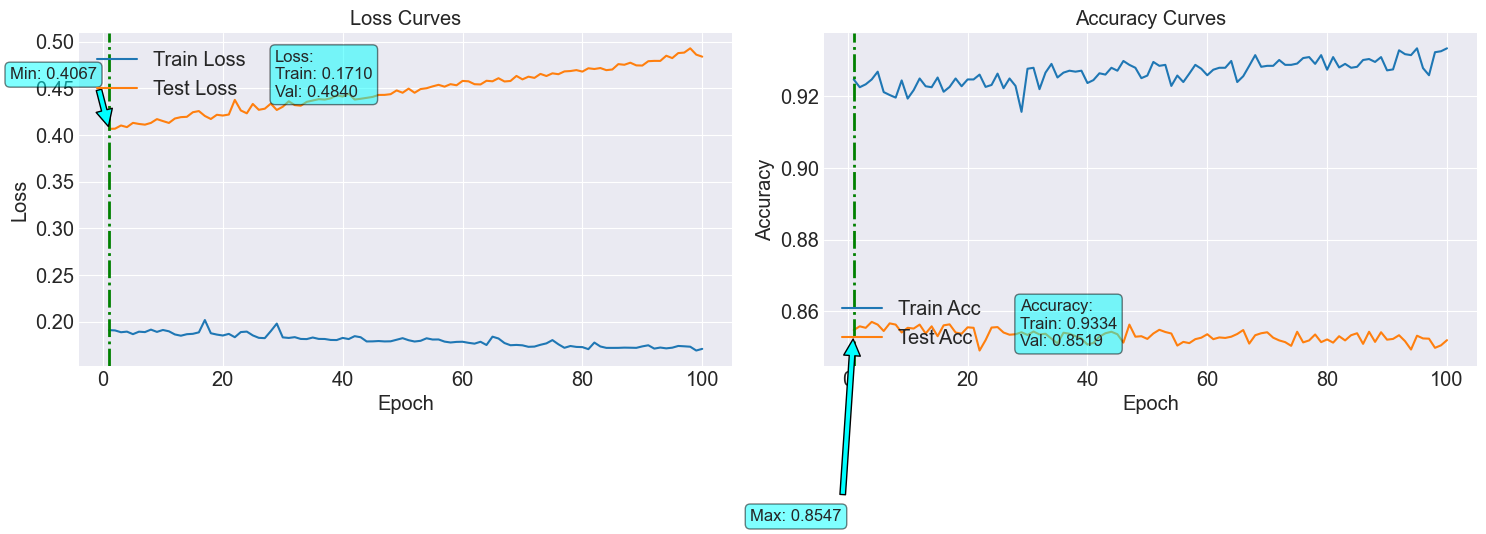

In [30]:
fn_plot_torch_hist(loss_df[1:])

## Performance on Train Dataset

In [31]:
y_true, y_pred = [], []

model.eval()

with torch.inference_mode():

    for batch_idx, (train_X, train_y) in enumerate(train_loader):
        train_X = train_X.to(device)
        
        pred = model(train_X)
        y_pred.extend(torch.argmax(pred, dim=1).cpu().numpy())
        y_true.extend(train_y)
        
    

display(accuracy_score(y_true, y_pred))

0.9353601752944399

In [32]:
print(classification_report(y_true, y_pred, target_names=list(class_names.values())))

              precision    recall  f1-score   support

 Goal Keeper       1.00      1.00      1.00       407
    Defender       0.97      0.96      0.97      1180
 Mid-Fielder       0.90      0.93      0.92      1376
     Forward       0.91      0.86      0.88       688

    accuracy                           0.94      3651
   macro avg       0.94      0.94      0.94      3651
weighted avg       0.94      0.94      0.94      3651



In [33]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_true, y_pred, average='weighted'):0.4f}")
    plt.show()

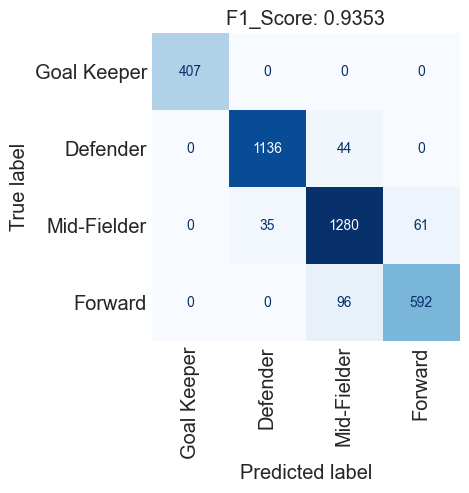

In [34]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)

## Performance on test dataset

In [35]:
y_true, y_pred = [], []

model.eval()

with torch.inference_mode():

    for batch_idx, (test_X, test_y) in enumerate(test_loader):
        test_X = test_X.to(device)
        
        pred = model(test_X)
        y_pred.extend(torch.argmax(pred, dim=1).cpu().numpy())
        y_true.extend(test_y)
        
    

display(accuracy_score(y_true, y_pred))

0.8518901766004415

In [36]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_true, y_pred, average='weighted'):0.4f}")
    plt.show()

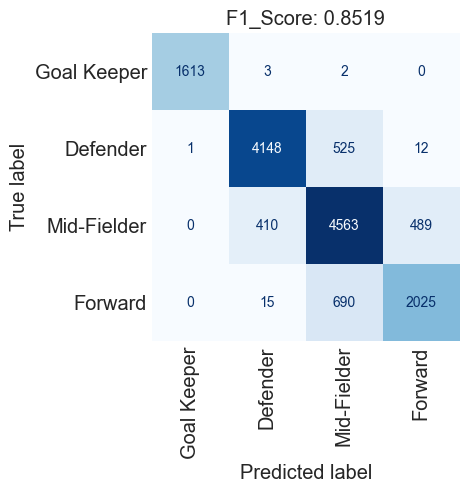

In [37]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)